In [1]:
import sys
import os
import h5py
from pathlib import Path
from datetime import datetime

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from helpers.config import *
from model_training.model import *

import torch
from torch.utils.data import Dataset, Subset, random_split, DataLoader
import torchvision.models as models
import torch.nn as nn
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [83]:
model = CNN(width=4, bn=True, normalise=False)
device = torch.device("mps")
results_dir = TRAINING_RESULTS / 'low_mass' /'run_260626_151227'
#results_dir = TRAINING_RESULTS / 'low_mass' /'run_260626_131722'
weights_path = results_dir /'best_model_weights.pth'
#weights_path = TRAINING_RESULTS/'low_mass'/ 'good_runs' /'run_090326_150123'/'best_model_weights.pth'

model.load_state_dict(torch.load(weights_path, map_location=device))
model.to(device)
model.eval()


CNN(
  (conv1): Conv2d(3, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.0, inplace=False)
  (fc1): Linear(in_features=8192, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=2, bias=True)
)

## Confusion matrix

In [3]:
DEVICE = torch.device("mps")
def accuracy(model, loader, threshold=0.5):
    model.eval()
    
    soft_correct, hard_correct, soft_total, hard_total = 0, 0, 0, 0
    with torch.no_grad():
        for batch in loader:
            images, labels = batch[0].to(DEVICE), batch[1].to(DEVICE)
            
            outputs = model(images)
            predicted = (torch.sigmoid(outputs) > threshold).float()
            soft_correct += (predicted == labels).sum().item()
            hard_correct += ((predicted == labels).all(dim=1)).sum().item()
            soft_total += labels.numel()
            hard_total += labels.size(0)
    
    soft_acc = soft_correct/soft_total
    hard_acc = hard_correct/hard_total
    return soft_acc, hard_acc

In [84]:
dataset = LISADataset(training_lm_dataset_path)

unique_indices = np.unique(dataset.sim_indices)
all_indices = np.array(dataset.sim_indices)

rng = np.random.default_rng(67)
rng.shuffle(unique_indices)

n_total = len(unique_indices)
n_train = int(0.7 * n_total)
n_val   = int(0.2 * n_total)

train_sources = unique_indices[:n_train]
val_sources   = unique_indices[n_train:n_train+n_val]
test_sources  = unique_indices[n_train+n_val:]

train_indices = np.where(np.isin(all_indices, train_sources))[0]
val_indices   = np.where(np.isin(all_indices, val_sources))[0]
test_indices  = np.where(np.isin(all_indices, test_sources))[0]

train_dataset = Subset(dataset, train_indices)
val_dataset   = Subset(dataset, val_indices)
test_dataset  = Subset(dataset, test_indices)

In [82]:
train_loader = DataLoader(train_dataset, batch_size=64)
train_soft_acc, train_hard_acc = accuracy(model, train_loader)

val_loader = DataLoader(val_dataset, batch_size=64)
val_soft_acc, val_hard_acc = accuracy(model, val_loader)

test_loader = DataLoader(test_dataset, batch_size=64)
test_soft_acc, test_hard_acc = accuracy(model, test_loader)

print(f"Training Soft Accuracy: {train_soft_acc:.4f}, Training Hard Accuracy: {train_hard_acc:.4f}")
print(f"Validation Soft Accuracy: {val_soft_acc:.4f}, Validation Hard Accuracy: {val_hard_acc:.4f}")
print(f"Test Soft Accuracy: {test_soft_acc:.4f}, Test Hard Accuracy: {test_hard_acc:.4f}")

Training Soft Accuracy: 0.9958, Training Hard Accuracy: 0.9916
Validation Soft Accuracy: 0.9641, Validation Hard Accuracy: 0.9293
Test Soft Accuracy: 0.9595, Test Hard Accuracy: 0.9200


In [85]:
model.eval()

loader = DataLoader(test_dataset, batch_size=64)

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for batch in loader:
        images = batch[0].to(device)
        labels = batch[1]

        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_preds.append(preds.cpu())
        all_probs.append(probs.cpu())
        all_labels.append(labels)

preds = torch.cat(all_preds)
labels = torch.cat(all_labels)
probs = torch.cat(all_probs)

In [87]:
from sklearn.metrics import roc_curve, auc

probs = np.array(probs)
labels = np.array(labels)

fpr_gw, tpr_gw, _ = roc_curve(
    labels[:, 0],
    probs[:, 0]
)
fpr_glitch, tpr_glitch, _ = roc_curve(
    labels[:, 1],
    probs[:, 1]
)
auc_gw = auc(fpr_gw, tpr_gw)
auc_glitch = auc(fpr_glitch, tpr_glitch)

print("GW AUC =", auc_gw)
print("Glitch AUC =", auc_glitch)

np.savez(results_dir / 'roc_curves.npz',
         fpr_gw=fpr_gw,
        tpr_gw=tpr_gw,
        auc_gw=auc_gw,
        fpr_glitch=fpr_glitch,
        tpr_glitch=tpr_glitch,
        auc_glitch=auc_glitch)

GW AUC = 0.992212
Glitch AUC = 0.97033


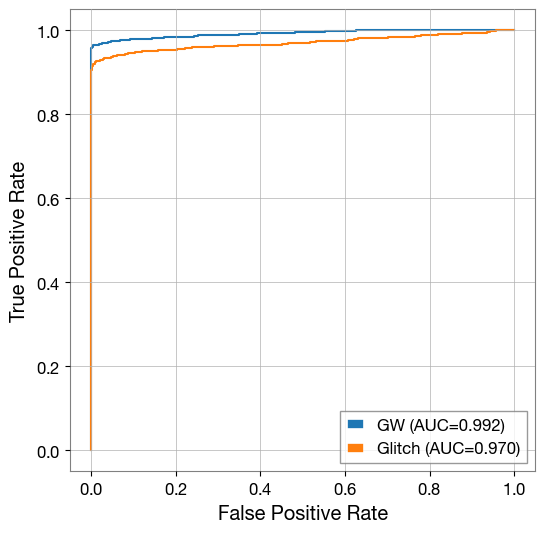

In [88]:
plt.figure(figsize=(6,6))

plt.plot(
    fpr_gw,
    tpr_gw,
    label=f'GW (AUC={auc_gw:.3f})'
)

plt.plot(
    fpr_glitch,
    tpr_glitch,
    label=f'Glitch (AUC={auc_glitch:.3f})'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.show()

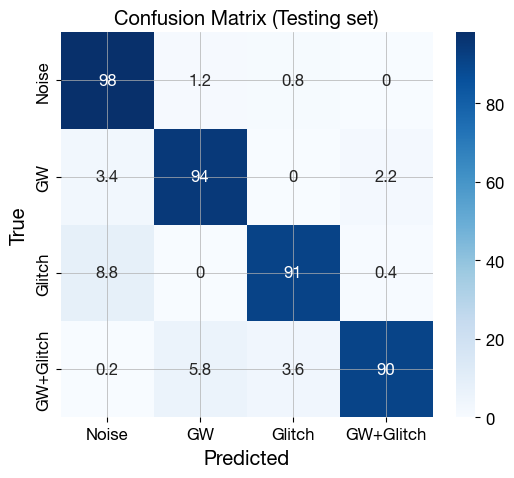

In [86]:
def label_to_class(y):
    return y[:,0]*1 + y[:,1]*2

true_class = label_to_class(labels)
pred_class = label_to_class(preds)
cm = confusion_matrix(true_class, pred_class, normalize='true')*100
np.savez(results_dir / 'confusion_matrix.npz', cm=cm)

labels_names = ["Noise", "GW", "Glitch", "GW+Glitch"]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap="Blues",
            xticklabels=labels_names,
            yticklabels=labels_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Testing set)")

plt.show()

In [7]:
np.where((true_class == 3)&(pred_class == 1))[0][0:40]

array([1000, 1010, 1040, 1041, 1042, 1043, 1044, 1052, 1100, 1101, 1102,
       1103, 1104, 1185, 1187, 1189, 1230, 1231, 1232, 1233, 1234, 1292,
       1295, 1296, 1297, 1298, 1299, 1357, 1360, 1361, 1362, 1364, 1412,
       1413, 1445, 1446, 1447, 1448, 1449, 1451])

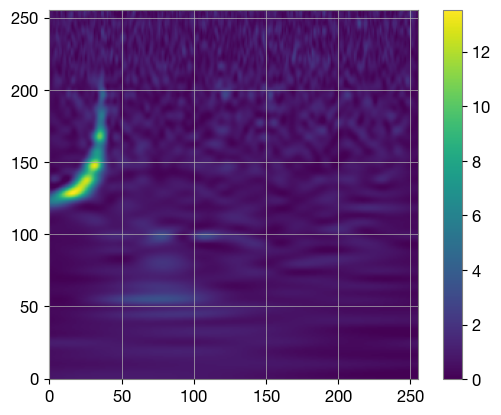

True label: tensor([1., 1.])
Sim index: 611
Time index: 2


In [30]:
image, label, sim_index, time_index = test_dataset[1292]
plt.imshow(image[0], origin='lower')
plt.colorbar()
plt.show()
print('True label:', label)
print('Sim index:', sim_index)
print('Time index:', time_index)

In [9]:
wrong = np.where((true_class == 3)&(pred_class == 1))[0]
wrong_sims = [test_dataset[i][2] for i in wrong]

right = np.where((true_class == 3)&(pred_class == 1))[0]
right_sims = np.array([test_dataset[i][2] for i in right])

wrong_times = np.array([test_dataset[i][3] for i in wrong])

In [10]:
with h5py.File(mixed_lm_dataset_path, 'r') as f:
    QT_arr = f['QT'][:]
    t_arr = f['t_qscan'][:]
    f_arr = f['f_qscan'][:]
    X_arr = f['X'][:]
    Y_arr = f['Y'][:]
    Z_arr = f['Z'][:]
    m1_arr = f['m1'][:]
    m2_arr = f['m2'][:]
    d_arr = f['d'][:]
    spin1_arr = f['spin1'][:]
    spin2_arr = f['spin2'][:]
    gw_beta_arr = f['gw_beta'][:]
    gw_lambda_arr = f['gw_lambda'][:]
    tcen_arr = f['tcen'][:]
    amp_arr = f['amp'][:]
    beta_arr = f['beta'][:]
    inj_point_arr = f['inj_point'][:]
    sep_arr = f['sep'][:]

In [11]:
wrong_images = QT_arr[wrong_sims, wrong_times, :, :, :]
wrong_taxes = t_arr[wrong_sims, wrong_times]
wrong_faxes = f_arr[wrong_sims, wrong_times]
wrong_X = X_arr[wrong_sims]
wrong_Y = Y_arr[wrong_sims]
wrong_Z = Z_arr[wrong_sims]
wrong_m1 = m1_arr[wrong_sims]
wrong_m2 = m2_arr[wrong_sims]
wrong_d = d_arr[wrong_sims]
wrong_spin1 = spin1_arr[wrong_sims]
wrong_spin2 = spin2_arr[wrong_sims]
wrong_gw_beta = gw_beta_arr[wrong_sims]
wrong_gw_lambda = gw_lambda_arr[wrong_sims]
wrong_tcen = tcen_arr[wrong_sims]
wrong_amp = amp_arr[wrong_sims]
wrong_beta = beta_arr[wrong_sims]
wrong_inj_point = inj_point_arr[wrong_sims]
wrong_sep = sep_arr[wrong_sims]

In [41]:
np.where(wrong_amp > 1e-13)

(array([ 7, 21, 27, 39, 40, 41, 44]),)

In [68]:
index = 39
t_axis = wrong_taxes[index]/3600
f_axis = wrong_faxes[index]
image = wrong_images[index, :, :, 0]
X = wrong_X[index]
Y = wrong_Y[index]
Z = wrong_Z[index]
m1 = wrong_m1[index]
m2 = wrong_m2[index]
d = wrong_d[index]
spin1 = wrong_spin1[index]
spin2 = wrong_spin2[index]
gw_beta = wrong_gw_beta[index]
gw_lambda = wrong_gw_lambda[index]
amp = wrong_amp[index]
beta = wrong_beta[index]
inj_point = wrong_inj_point[index]
sep = wrong_sep[index]
tcen = wrong_tcen[index]

In [69]:
sep

np.float32(0.8329617)

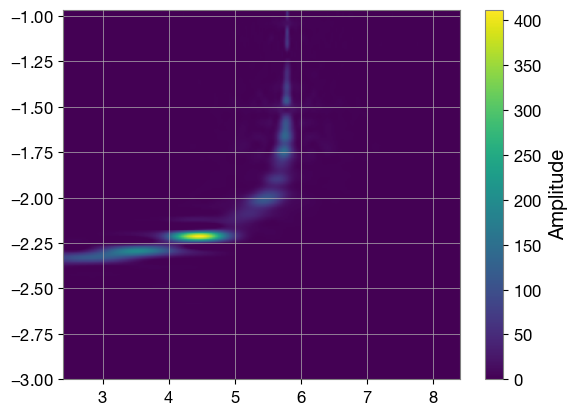

In [70]:
plt.imshow(image, extent=[t_axis[0], t_axis[-1], np.log10(f_axis[0]), np.log10(f_axis[-1])], aspect='auto', origin='lower')
plt.colorbar(label='Amplitude')
plt.show()

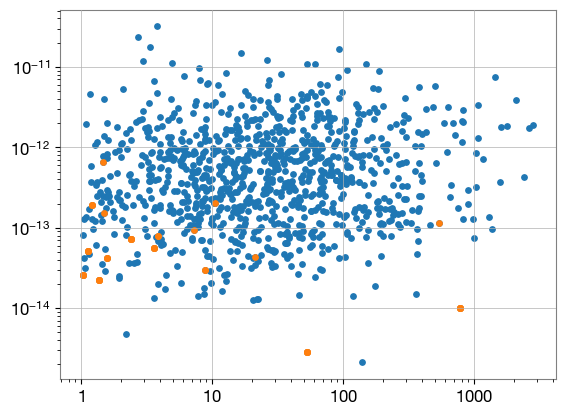

In [42]:
plt.scatter(beta_arr, amp_arr, s=15)
plt.scatter(wrong_beta, wrong_amp, s=15)
plt.xscale('log')
plt.yscale('log')
plt.show()

In [45]:
#orbits_path2 = str(DIST / 'orbits' / 'orbits2.h5')
from helpers.simulation import *

with h5py.File(orbits_path, 'r') as orb:
    orb_t0 = orb.attrs['t0']
    orb_size = orb.attrs['size']
    orb_dt = orb.attrs['dt']
    
pipe = {'t0': orb_t0 + orb_size*orb_dt/2, 'dt': 0.25,'size': int(10 * 3600 / 0.25),
        't_inj': 5 * 3600, 'keep_noises': ['test-mass', 'oms']}

gws = [{'type': 'BinaryInspiralGW', 'm1': m1, 'm2': m2, 'd': d,
        'spin1': spin1, 'spin2': spin2, 't_inj': pipe['t_inj']+sep*3600, 'domain': 'freq',
        'gw_beta':gw_beta, 'gw_lambda':gw_lambda}]
glitches = [{'type':'IntegratedShapeletGlitch', 't_inj': pipe['t_inj']-sep*3600, 'beta': beta,
             'level':2*amp*beta, 'inj_point':inj_point.decode('utf-8')}]

run_simulation(
            gws, glitches, pipe,
            gw_path, glitch_path, orbits_path,
            simulation_path,
            disable_noise=['test-mass', 'oms']
        )
raw_dict = run_tdi(simulation_path, pipe)

You are using an orbit file in a version that might not be fully supported
Cannot read sampling parameters from '/Users/aryamannrao/Documents/MSc/LISAGlitchSignalClassifier/dist/default_gw_output.h5'
You are using an orbit file in a version that might not be fully supported
Using default set of locking beatnote frequencies might cause interferometric beatnote frequencies to fall outside the requirement range of 5..25 MHz
You are using a measurement file in a version that might not be fully supported (got '2.1.0', official support up to '2.0')


In [63]:
from helpers.qtransform import *

event = {'t_inj':pipe['t_inj']}
res = 256
spec = SPECS['ext_high_mass']
tdi_dict = make_tdi_dict(raw_dict['X'], raw_dict['Y'], raw_dict['Z'], whiten=True)

QT_mixed = np.zeros((256, 256, 3))
for channel in ['A', 'E', 'T']:
    t_mixed, f_mixed, data = generate_qscan(tdi_dict, channel, pipe, event, resolution=res,
                             frange=(1e-3, 1e-1), trange=(-3, 3), Q=15)
    QT_mixed[:, :, ['A', 'E', 'T'].index(channel)] = data


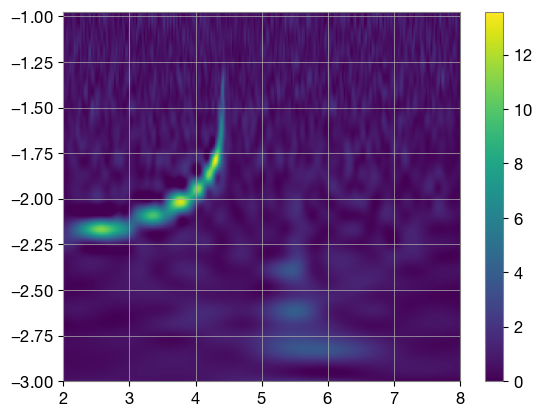

1.5150838e-13 1.4857904


In [64]:
plt.imshow(QT_mixed[:, :, 0], extent=[t_mixed[0]/3600, t_mixed[-1]/3600, np.log10(f_mixed[0]), np.log10(f_mixed[-1])], aspect='auto', origin='lower')
plt.colorbar()
#plt.clim(0, 5)
plt.show()

print(amp, beta)

In [36]:
with h5py.File(mixed_lm_dataset_path, 'r') as f:
    amp_arr = f['amp'][:]
    beta_arr = f['beta'][:]

mixed_lm_dataset_path2 = MIXED_DATASETS / 'mixed_lm_dataset2.h5'
with h5py.File(mixed_lm_dataset_path2, 'r') as f:
    amp_arr2 = f['amp'][:]
    beta_arr2 = f['beta'][:]


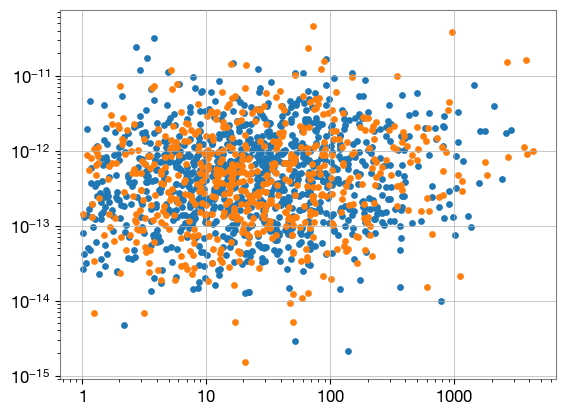

In [37]:
plt.scatter(beta_arr, amp_arr, s=15)
plt.scatter(beta_arr2, amp_arr2, s=15)
plt.xscale('log')
plt.yscale('log')
plt.show()